# MIT 6.7960 Fall 2026 PyTorch Tutorial:

This colab was originally adapted from both https://github.com/davidbau/how-to-read-pytorch and https://pytorch.org/tutorials/beginner/basics/intro.html, which are great resources if you’re interested in learning more.

Also see last year's PyTorch tutorial https://colab.research.google.com/drive/1nZg9_wYpVYWS9xZAiSft5_gyluuQpBWY?usp=sharing, which this notebook is an abridged version of.



Pytorch and its key features
===================

Pytorch code is short, and a great deal happens per line. Consider:

```
torch.nn.functional.cross_entropy(model(images.cuda()), labels.cuda()).backward()
optimizer.step()
```

Those two lines move a batch onto the GPU, run the network, record how the loss depends on every parameter, compute a gradient for each one, and update all of them — without the CPU ever seeing a number. That is deliberate: a few python instructions load a lot of work onto the GPU, which is why a slow interpreter can still drive fast training.

Knowing what the runtime is doing on your behalf is most of what it takes to read and write pytorch, so that is what the next five topics are about: **tensors**, **autograd**, **optimizers**, **modules**, and **data**.

In [ ]:
import math
import numpy as np
import torch
from matplotlib import pyplot as plt

Topic 1: Pytorch Tensors
===============

A [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html) holds a d-dimensional array of numbers and is a deliberate lookalike for [`numpy.ndarray`](https://numpy.org/doc/stable/reference/arrays.ndarray.html): almost every numpy operation has a torch equivalent.

**Two things tensors have that numpy arrays lack:**

 1. They can live on **GPU or CPU** (numpy is CPU-only).
 2. They can **track their own computation history**, which is what makes automatic differentiation possible (Topic 2).

## 1.1 What is a tensor?

Every torch tensor can be thought of as a (potentially nested) array of numbers. We initially consider 3 major properties: data type, shape, and device. Later, we'll see tensors' ability to track their gradients and computation graphs.

### Creating a tensor from data

`torch.tensor(...)` builds a tensor from Python lists and infers the dtype from what you gave it: whole numbers become `int64`, decimals become `float32`. Pass `dtype=` to override that. `torch.from_numpy(...)` wraps an existing numpy array instead.

In [ ]:
t = torch.tensor([[1, 2], [3, 4]])
print(t, t.dtype)

t = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
print(t, t.dtype)

print(torch.from_numpy(np.array([[1.0, 2.0], [3.0, 4.0]])))

tensor([[1, 2],
        [3, 4]]) torch.int64
tensor([[1., 2.],
        [3., 4.]]) torch.float32
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)


### Creating a tensor from a shape

Suppose you do not have the data yet and just want a tensor of a given size: `zeros`, `ones`, and `randn` (samples from a standard normal) all take a shape.
The PyTorch `shape` class subclasses tuple! The `_like` variants take a tensor instead and copy its shape and dtype. `arange` and `linspace` are the two range constructors you will reach for constantly.

In [ ]:
print(torch.zeros(2, 3))
print(torch.ones(2, 3))
print(torch.randn(2, 3))

print(torch.arange(5))
print(torch.linspace(0, 1, 5))

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[-1.0225,  0.3101,  2.4418],
        [-0.5027, -0.1924,  0.2084]])
tensor([0, 1, 2, 3, 4])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


In [ ]:
x = torch.randn(4, 5)

print(torch.zeros_like(x).shape)
print(torch.ones_like(x).shape)
print(torch.randn_like(x).shape)

torch.Size([4, 5])
torch.Size([4, 5])
torch.Size([4, 5])


### Copying a tensor

`y = x` aliases the tensor x. `x.clone()` makes an independent copy, and it stays part of the autograd graph (see later), so cloning a parameter does not sever it from its gradients.

In [ ]:
x = torch.ones(3)
y = x
z = x.clone()

x[0] = 99
print(y)
print(z)

tensor([99.,  1.,  1.])
tensor([1., 1., 1.])


### The three attributes every tensor has

**`shape`** is the size along each dimension, **`dtype`** is the number format, and **`device`** is where the memory lives. These three are what you print when something goes wrong, which is most of the time.

In [ ]:
x = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
print(x.shape, x.dtype, x.device)

y = torch.tensor([1, 2, 3])
print(y.shape, y.dtype, y.device)

torch.Size([2, 3]) torch.float32 cpu
torch.Size([3]) torch.int64 cpu


### Changing the device

`x.to(device)` returns a **copy** of the tensor on that device, so remember to assign the result. Two tensors must be on the same device to be combined with each other, and a tensor must be back on the CPU before numpy will touch it.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

x = torch.randn(2, 3).to(device)
print(x.device)

print(x.cpu().numpy())

cuda
cuda:0
[[ 0.37361437  1.1608425  -0.3499447 ]
 [-0.49153587  1.7153903  -1.0208201 ]]


*We can now make a tensor of any shape and dtype, and put it on any device.*

## 1.2 Math on tensors

Math on tensors is elementwise.

### Math is elementwise by default

Arithmetic and most methods run on every element independently and hand back a tensor of the same shape.

In [ ]:
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([10.0, 20.0, 30.0])

print(x + y)
print(x * y)
print(x.pow(2))
print(x.sin())

x += y
print(x)

tensor([11., 22., 33.])
tensor([10., 40., 90.])
tensor([1., 4., 9.])
tensor([0.8415, 0.9093, 0.1411])
tensor([11., 22., 33.])


### `*` is elementwise, `@` is matrix multiplication

`A @ B` (equivalently `A.matmul(B)`) contracts the last dimension of `A` against the first of `B`, so `(2, 3) @ (3, 4)` gives `(2, 4)`. `A * A` multiplies corresponding entries and keeps the shape it started with.

With more than two dimensions, `@` uses the **last two** as the matrix and treats every leading dimension as a batch to loop over. 'Elementwise' if you think of the last two dims as the one datapoint/element. So `(2, 3, 4) @ (2, 4, 5)` is two independent `(3, 4) @ (4, 5)` products, stacked back into `(2, 3, 5)`.

In [ ]:
A = torch.randn(3, 4)
B = torch.randn(4, 5)

print((A @ B).shape)
print((A * A).shape)

A = torch.randn(2, 3, 4)
B = torch.randn(2, 4, 5)

print((A @ B).shape)

torch.Size([3, 5])
torch.Size([3, 4])
torch.Size([2, 3, 5])


### Operations copy, unless they end in an underscore

`x.mul(2)` leaves `x` alone and returns a new tensor. `x.mul_(2)` overwrites `x` in place. Every in-place variant ends in `_`, and you will see this again with `zero_()` when we start clearing gradients.

In [ ]:
x = torch.ones(3)

y = x.mul(2)
print(x, y)

x.mul_(2)
print(x)

tensor([1., 1., 1.]) tensor([2., 2., 2.])
tensor([2., 2., 2.])


### `.item()` gets a plain Python number out

A one-element tensor is still a tensor, carrying a dtype, a device, and (later) a computation history. `.item()` gives you an ordinary Python float, which is what you want for printing a loss or appending it to a list.

In [ ]:
loss = torch.randn(4, 4).mean()

print(loss)
print(loss.item())

tensor(-0.0307)
-0.030675183981657028


*We can now do elementwise math and matrix products, in place or out of place.*

## 1.3 Playing with dimensions

We can select, combine, and summarize data along whichever dimension we want.

### Indexing and slicing

Exactly like numpy, including assigning into a slice.

In [ ]:
x = torch.tensor([[0.0, 1.0, 2.0, 3.0], [4.0, 5.0, 6.0, 7.0], [8.0, 9.0, 10.0, 11.0]])

print(x[0])
print(x[:, 0])
print(x[1, 2])

x[:, 1] = 0
print(x)

tensor([0., 1., 2., 3.])
tensor([0., 4., 8.])
tensor(6.)
tensor([[ 0.,  0.,  2.,  3.],
        [ 4.,  0.,  6.,  7.],
        [ 8.,  0., 10., 11.]])


### Boolean Indexing

Also like numpy/pandas! Remember masks are tensors, not lists.
torch.where(mask, x, y) takes the value of x when mask is True and y where mask
is False.

In [ ]:
x = torch.tensor([[0.0, 1.0, 2.0, 3.0], [4.0, 5.0, 6.0, 7.0], [8.0, 9.0, 10.0, 11.0]])

mask = (x % 2) == 0
print(mask)
print(x[mask])

print(torch.where(mask, x * x, x))

tensor([[ True, False,  True, False],
        [ True, False,  True, False],
        [ True, False,  True, False]])
tensor([ 0.,  2.,  4.,  6.,  8., 10.])
tensor([[  0.,   1.,   4.,   3.],
        [ 16.,   5.,  36.,   7.],
        [ 64.,   9., 100.,  11.]])


### Joining tensors: `cat` versus `stack`

`torch.cat` glues tensors together along a dimension that already exists, so two `(2, 3)` tensors become `(4, 3)` along `dim=0` or `(2, 6)` along `dim=1`. `torch.stack` instead creates a new dimension to hold them, giving `(2, 2, 3)` — this is how you assemble separate examples into a batch.

In [ ]:
a = torch.zeros(2, 3)
b = torch.ones(2, 3)

print(torch.cat([a, b], dim=0).shape)
print(torch.cat([a, b], dim=1).shape)
print(torch.stack([a, b], dim=0).shape)

torch.Size([4, 3])
torch.Size([2, 6])
torch.Size([2, 2, 3])


### Reductions collapse a dimension

`sum`, `mean`, `std`, `min`, `max`, and `norm` with no arguments reduce the whole tensor to a single number. With `dim=n` they reduce only along that dimension, which then disappears from the shape: summing a `(2, 3)` tensor along `dim=1` leaves `(2,)`. Passing a tuple, `dim=(0, 1)`, reduces over several dimensions at once.

Passing `keepdim=True` leaves the reduced dimension in place with size 1, giving `(2, 1)` instead. That is what lets the result line back up against the tensor it came from, which we use in the walkthrough.

In [ ]:
x = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])

print(x.sum())
print(x.sum(dim=0))
print(x.sum(dim=1))
print(x.sum(dim=(0, 1)))
print(x.sum(dim=1, keepdim=True).shape)

tensor(21.)
tensor([5., 7., 9.])
tensor([ 6., 15.])
tensor(21.)
torch.Size([2, 1])


### `max` and `min` also tell you *where*

Given a `dim`, they return two tensors rather than one: the values and the indices those values came from. No need for seperate argmax calls!

In [ ]:
x = torch.tensor([[1.0, 9.0, 3.0], [4.0, 5.0, 6.0]])

values, indices = x.max(dim=1)
print(values)
print(indices)

tensor([9., 6.])
tensor([1, 2])


*We can now pull out any slice of a tensor, combine tensors, and summarize along any dimension.*

## 1.4 Conventions in dimensions

We use conventions to line dimensions up, often implicitly.

### The big 4D objects

**Data** is ordered `[batch, channel, y, x]`. Data without grid geometry drops the trailing dimensions, and 3d grid data adds a `z` before `y`.

**Weights** are ordered `[out_features, in_features, kernel_y, kernel_x]`, output first — so a `Linear(10, 5)` layer stores a `(5, 10)` weight matrix.

Data puts the *batch* in dimension 0 while weights put *output features* in dimension 0. That mismatch is why you will see a transpose in front of so many matrix multiplies: `W.T` swaps the last two dimensions, turning the `(5, 10)` weight into the `(10, 5)` matrix that a `(64, 10)` batch can actually be multiplied by.

In [ ]:
images = torch.randn(64, 3, 32, 32)
print(images.shape)

layer = torch.nn.Linear(10, 5)
print(layer.weight.shape)

x = torch.randn(64, 10)
print((x @ layer.weight.T).shape)

torch.Size([64, 3, 32, 32])
torch.Size([5, 10])
torch.Size([64, 5])


### Rearranging: `view`, `reshape`, and `permute`

`view` regroups the same numbers into a new shape and `permute` reorders the dimensions. Neither one moves any data — they only change how the underlying block of memory is read — so both are cheap. A `-1` in a shape means "infer this one from the number of elements."

Some permute-then-flatten combinations cannot be expressed as a view of the original memory. `reshape` handles those by copying when it has to, which makes it the safer default. Generally, use `reshape`!

`unsqueeze(n)` and `squeeze(n)` are the special case of adding and removing a dimension of size 1. Since pytorch models always expect a batch dimension, this is how you hand one a single example, and how you strip the leftover dimension off afterwards.

In [ ]:
x = torch.randn(2, 3, 4)

print(x.view(2, 12).shape)
print(x.view(2, -1).shape)
print(x.permute(0, 2, 1).shape)
print(x.reshape(2, -1).shape)

print(x.unsqueeze(0).shape)
print(x.unsqueeze(0).squeeze(0).shape)

torch.Size([2, 12])
torch.Size([2, 12])
torch.Size([2, 4, 3])
torch.Size([2, 12])
torch.Size([1, 2, 3, 4])
torch.Size([2, 3, 4])


### Broadcasting

Shapes that do not match can still be combined. Line the two shapes up **from the right** and read down each column: equal is fine, a `1` stretches to match the other side, and a dimension that is not there counts as `1`. Anything else is an error.

Nothing is copied — a stretched dimension just reads the same memory over and over. [Full rules here](https://pytorch.org/docs/stable/notes/broadcasting.html).

In [ ]:
batch = torch.randn(100, 4)
mean = batch.mean(dim=0)

# batch   (100, 4)
# mean         (4,)   missing dimension counts as 1, so it stretches to 100
print((batch - mean).shape)  # (100, 4)


images = torch.randn(16, 3, 8, 8)
W = torch.randn(8, 800)

# images  (16, 3,  8,  8)   last two dims are the matrix
# W       (    2   8, 12)   the rest broadcasts: 3 vs nothing -> 3, 16 vs nothing -> 16
print((images @ W).shape)  # (16, 3, 8, 12)

torch.Size([100, 4])
torch.Size([16, 3, 8, 800])


*We can now get any tensor into the shape the next operation expects.*

## Walkthrough: a forward pass with nothing but tensors

Here is a batch of images running through one linear layer, using only the operations above and nothing else. `torch.nn` will do all of this for us later, but it is worth seeing once without the abstraction in the way. Watch the shapes at each step.

In [ ]:
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

# A batch of 16 RGB 8x8 "images", in the standard [batch, channel, y, x] order
images = torch.randn(16, 3, 8, 8).to(device)
print(f"images:  {tuple(images.shape)}")

# 1. Normalize each channel: average over batch and space, but not over channels
mean = images.mean(dim=(0, 2, 3), keepdim=True)
std = images.std(dim=(0, 2, 3), keepdim=True)
images = (images - mean) / std
print(f"mean:    {tuple(mean.shape)} broadcast against {tuple(images.shape)}")

# 2. Flatten each image into one long vector
flat = images.reshape(images.shape[0], -1)
print(f"flat:    {tuple(flat.shape)}")

# 3. One linear layer by hand, with the weight stored as [out_features, in_features]
W = torch.randn(10, 192).to(device) * 0.01
b = torch.zeros(10).to(device)
logits = flat @ W.T + b
print(f"logits:  {tuple(logits.shape)}")

# 4. Scores into predictions
probs = logits.softmax(dim=1)
confidence, predicted = probs.max(dim=1)
print(f"predicted classes: {predicted}")
print(f"each row sums to 1: {probs.sum(dim=1)[:3]}")

images:  (16, 3, 8, 8)
mean:    (1, 3, 1, 1) broadcast against (16, 3, 8, 8)
flat:    (16, 192)
logits:  (16, 10)
predicted classes: tensor([4, 6, 2, 5, 8, 9, 9, 8, 3, 4, 9, 9, 9, 3, 8, 1], device='cuda:0')
each row sums to 1: tensor([1., 1., 1.], device='cuda:0')


Topic 2: Autograd
================

Deep learning is just repeated gradient descent, so the whole library rests on being able to differentiate anything you can write. Pytorch does this by **recording every operation as you run it** and then replaying that record backwards.

<img src="https://raw.githubusercontent.com/davidbau/how-to-read-pytorch/6ce891301e79aa8e2164a703c08257a52b2d1ad3/notebooks/autograd-graph.png" style="max-width:100%">

## 2.1 Tracking a computation

A tensor can remember where it came from.

### `requires_grad` turns tracking on

Flag a tensor with `requires_grad=True` and pytorch starts recording every operation that touches it. An existing tensor can be flagged after the fact with `x.requires_grad_(True)` — the underscore rule again. Anything computed from a tracked tensor comes back with a `grad_fn`, the record of how it was made and the node that knows how to reverse this step.

In [ ]:
x = torch.tensor([2.0], requires_grad=True)
y = (x**2).sum()

print(y)
print(y.grad_fn)

tensor(4., grad_fn=<SumBackward0>)


### `torch.autograd.grad` computes the derivative

`torch.autograd.grad(output, [inputs])` walks that record backwards and returns d(output)/d(input) for each input you asked about. The output has to be a **single number**, which is why you will see `.sum()` everywhere: for a function applied elementwise, the derivative of the sum with respect to each entry is just that entry's own derivative.

In [ ]:
x = torch.linspace(0, 5, 100, requires_grad=True)
y = (x**2).cos()

[dydx] = torch.autograd.grad(y.sum(), [x])
print(dydx.shape)
print(dydx[:4])

torch.Size([100])
tensor([-0.0000, -0.0003, -0.0021, -0.0070])


### Multiple Derivatives on the Same Graph

Ask for `df/dx` and `df/dy` separately and the second call fails: the recorded graph is freed as soon as it has been walked once, since holding it would waste memory in the common case. `retain_graph=True` keeps it alive for another pass.

Note the best approach here is to just do `torch.autograd.grad(f, [x, y])`.

In [ ]:
x = torch.tensor([2.0], requires_grad=True)
y = torch.tensor([3.0], requires_grad=True)
f = ((x**2) * y).sum()

[dfdx, dfdy] = torch.autograd.grad(f, [x, y])

print(dfdx, dfdy)

tensor([12.]) tensor([4.])


### `detach` steps back out of the graph

A tensor that requires grad refuses to convert to numpy, because that conversion would leave the graph without pytorch noticing. `x.detach()` gives you the same numbers with the history stripped off, which is what you want before plotting or logging.

In [ ]:
x = torch.linspace(0, 1, 5, requires_grad=True)
y = x * 2

print(y.requires_grad)
print(y.detach().requires_grad)

True
False


*We can now ask for the derivative of any scalar with respect to any tensor it was built from.*

## 2.2 Backpropagation

Real networks have tons of parameters, so keeping track of everything would be a massive pain. It's best for gradients to be delivered to the parameters themselves.

### `.backward()` puts gradients in `.grad`

Catching return values works for two inputs, not for a network with three hundred parameter tensors. Since a gradient has exactly the same shape as the thing it differentiates, pytorch hangs it on that tensor instead: `loss.backward()` runs backprop over the whole graph and fills in `.grad` on every tensor marked `requires_grad=True`.

This is the call you will actually use. `torch.autograd.grad` is for when you want a gradient as a value — higher-order derivatives, or a gradient penalty — rather than accumulated onto parameters.

In [ ]:
x = torch.tensor([3.0], requires_grad=True)
y = (x**2).sum()
y.backward()

print(x.grad)

tensor([6.])


### Gradients accumulate, so clear them

Calling `.backward()` again **adds** to whatever is already in `.grad` rather than replacing it. That is deliberate — it lets you split a batch too large for memory into pieces and sum their gradients — but a forgotten reset silently corrupts training.

`x.grad.zero_()` resets in place (there is that underscore again). In practice you will call `optimizer.zero_grad()`, which does this for every parameter at once, and we will see it in the next topic.

In [ ]:
x = torch.tensor([3.0], requires_grad=True)

(x**2).sum().backward()
print(x.grad)

(x**2).sum().backward()
print(x.grad)

x.grad.zero_()
(x**2).sum().backward()
print(x.grad)

tensor([6.])
tensor([12.])
tensor([6.])


### `torch.no_grad()` when you are not training

Every tracked operation holds onto intermediate tensors so they can be reused on the backward pass, which costs real GPU memory. If you are only running the network to look at its predictions, wrap the call in `with torch.no_grad():` and none of that is kept.

This is about *memory and speed*, not about network behavior. The related `net.eval()` — which changes how dropout and batchnorm act — is a separate switch, covered in Topic 4.

In [ ]:
x = torch.tensor([3.0], requires_grad=True)

with torch.no_grad():
    y = (x**2).sum()

print(y.requires_grad)

False


*We can now get gradients for every input at once, and control when they accumulate.*

## Walkthrough: derivatives we never had to write down

First the one-dimensional case, where we can check the answer by eye: plot `cos(x²)` next to the gradient autograd computed for it.

In [ ]:
# @title Run this cell to set up the plotting helper for the 2-D example
def plot_2d(Z, dZdx, dZdy, extent=(-3, 3, -3, 3)):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    panels = [(Z, "f(x, y)"), (dZdx, "df/dx"), (dZdy, "df/dy")]
    for ax, (data, title) in zip(axes, panels):
        im = ax.imshow(data.detach().cpu(), extent=extent, origin="lower", cmap="RdBu")
        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        fig.colorbar(im, ax=ax)
    plt.show()

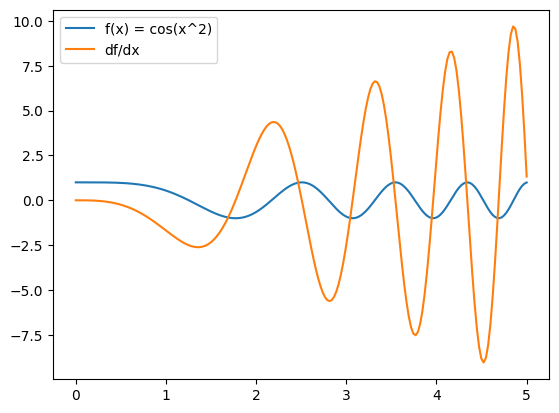

In [ ]:
x = torch.linspace(0, 5, 200, requires_grad=True)
y = (x**2).cos()

y.sum().backward()

plt.plot(x.detach(), y.detach(), label="f(x) = cos(x^2)")
plt.plot(x.detach(), x.grad, label="df/dx")
plt.legend()
plt.show()

Now the same thing on a function of **two** inputs, `f(x, y) = sin(x)·cos(y)`, evaluated on a grid. One `backward()` call fills in `X.grad` and `Y.grad` — two different partial derivatives, each landing on the tensor it belongs to.

Nothing here is named `df_dx` or `df_dy`, and there is no `retain_graph` — one `backward()` call filled in both. With a hundred parameters instead of two, the bookkeeping does not change at all. (`torch.meshgrid` just builds the two coordinate grids to evaluate on.)

torch.Size([60, 60]) torch.Size([60, 60])


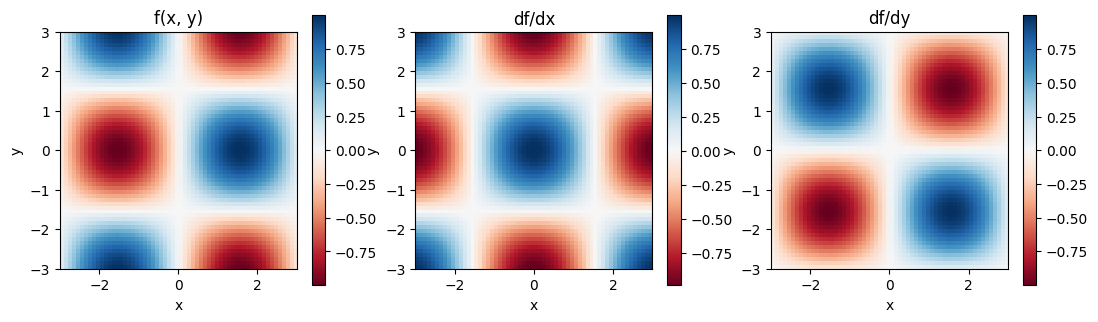

In [ ]:
grid = torch.linspace(-3, 3, 60)
X, Y = torch.meshgrid(grid, grid, indexing="xy")
X = X.clone().requires_grad_(True)
Y = Y.clone().requires_grad_(True)

Z = X.sin() * Y.cos()
Z.sum().backward()

print(X.grad.shape, Y.grad.shape)
plot_2d(Z, X.grad, Y.grad)

Topic 3: Optimizers
================

You already know what SGD and Adam do. This topic is only about what they look like in pytorch, and what they are doing on your behalf.

## 3.1 Optimizers

An optimizer is a rule for turning `.grad` into a parameter update.

### Creating one, and the three lines you will write forever

An optimizer is constructed with the list of tensors it is allowed to change, plus its hyperparameters. It holds references to those exact tensors, so updating them is something it does in place.

Every training loop then contains the same three calls, in this order: clear the old gradients, run backward to fill in new ones, let the optimizer apply them. Getting the order wrong, or dropping `zero_grad`, is the most common bug in a first training loop.

In [ ]:
x = torch.tensor([5.0, -3.0], requires_grad=True)
optimizer = torch.optim.SGD([x], lr=0.1, momentum=0.9)
print(optimizer)

loss = (x**2).sum()

optimizer.zero_grad()
loss.backward()
print(x.grad)
optimizer.step()

print(x)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)
tensor([10., -6.])
tensor([ 4.0000, -2.4000], requires_grad=True)


### Adam is a drop-in replacement

Every optimizer in `torch.optim` exposes the same `zero_grad` / `step` interface, so switching algorithms is a one-line change and the loop never moves. Adam adapts a per-parameter step size as it goes and is the usual default; `lr=3e-4` is a reasonable starting point for it.

In [ ]:
x = torch.tensor([5.0, -3.0], requires_grad=True)
optimizer = torch.optim.Adam([x], lr=0.1)

for step in range(50):
    loss = (x**2).sum()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(x)

tensor([0.9011, 0.1689], requires_grad=True)


### Learning rate schedules

A scheduler wraps an optimizer and rewrites its learning rate as training goes on. You call `scheduler.step()` once per epoch, after `optimizer.step()`, and read the current rate with `get_last_lr()`.

`CosineAnnealingLR` is the cosine decay you have seen in lecture: `T_max` is the number of steps to go from the optimizer's starting `lr` down to `eta_min`. `StepLR`, `LinearLR`, `OneCycleLR` and [the rest](https://pytorch.org/docs/stable/optim.html) all swap in the same way.

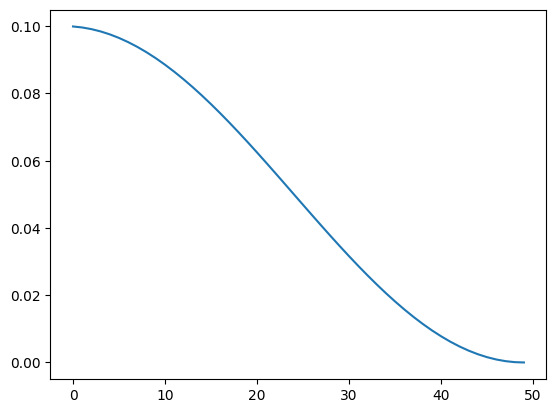

In [ ]:
optimizer = torch.optim.SGD([x], lr=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

lrs = []
for epoch in range(50):
    optimizer.step()
    scheduler.step()
    lrs.append(scheduler.get_last_lr()[0])

plt.plot(lrs)
plt.show()

*We can now update parameters with any algorithm in `torch.optim`, and decay the learning rate as training goes on.*

## Walkthrough: the same descent, with and without the optimizer

`torch.optim.SGD` is convenient, not magic. Here is the same problem solved twice — once by subtracting the gradient by hand, once through the optimizer API — from the same starting point, so you can see they land in the same place.

First, by hand. Note the `torch.no_grad()` block: we are changing `x` as data, and we do not want that edit recorded as part of the next graph. The blue ellipses are level sets of the loss, and the marked path is where `x` went.

In [ ]:
# @title Run this cell to set up plot_progress(), which draws the descent path
def plot_progress(bowl, track, losses):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    for size in torch.linspace(0.1, 1.0, 10):
        angle = torch.linspace(0, 6.3, 100)
        circle = torch.stack([angle.sin(), angle.cos()])
        ellipse = torch.inverse(bowl) @ circle * size
        ax1.plot(ellipse[0, :], ellipse[1, :], color="skyblue")
    path = torch.stack(track).t()
    ax1.plot(path[0, :], path[1, :], marker="o")
    ax1.set_title("path of x")
    ax1.set_xlabel("x[0]")
    ax1.set_ylabel("x[1]")
    ax1.set_xlim(-1.6, 1.6)
    ax1.set_ylim(-1, 1)
    ax2.plot(range(len(losses)), losses, marker="o")
    ax2.set_title("loss")
    ax2.set_xlabel("iteration")
    plt.show()

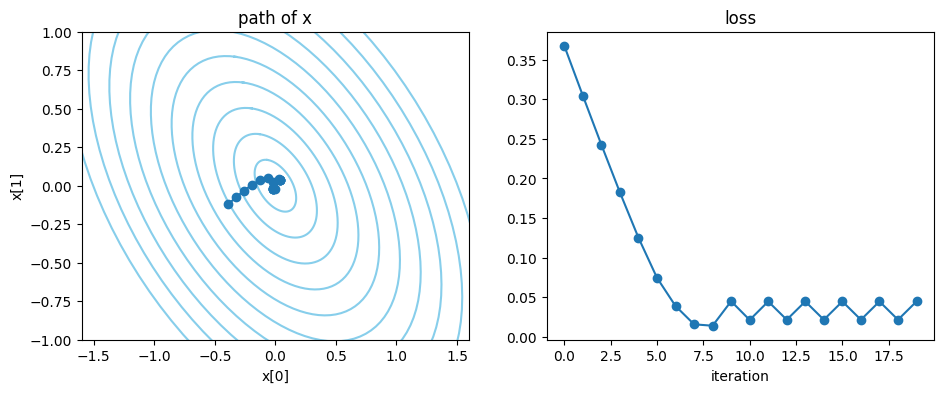

In [ ]:
torch.manual_seed(1)
bowl = torch.randn(2, 2)  # transforms axes
x_init = torch.randn(2)

x = x_init.clone().requires_grad_(True)
track, losses = [], []

for step in range(20):
    loss = (bowl @ x).norm()
    loss.backward()
    with torch.no_grad():
        x -= 0.1 * x.grad
        x.grad.zero_()
    track.append(x.detach().clone())
    losses.append(loss.item())

plot_progress(bowl, track, losses)

And now the same twenty steps through `torch.optim.SGD`. The loop body is the three lines from earlier, `optimizer.step()` is doing exactly the subtraction we just wrote out, and the path below is identical.

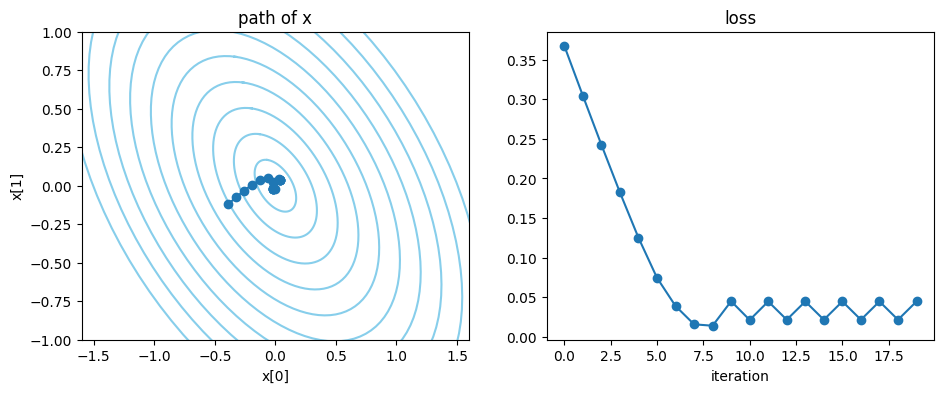

In [ ]:
x = x_init.clone().requires_grad_(True)
optimizer = torch.optim.SGD([x], lr=0.1)
track, losses = [], []

for step in range(20):
    loss = (bowl @ x).norm()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    track.append(x.detach().clone())
    losses.append(loss.item())

plot_progress(bowl, track, losses)

Topic 4: Neural Network Modules
================

A `torch.nn.Module` is a callable object that owns its parameters. That is the whole idea: it bundles some trainable tensors together with the math that uses them, and knows how to list, move, and save them as a unit.

## 4.1 Writing a module

Parameters go in `__init__`, math goes in `forward`.

### Subclassing `nn.Module`

Two rules. Call `super().__init__()` first, or nothing else will work. Wrap trainable tensors in `torch.nn.Parameter`, which marks them `requires_grad=True` and registers them with the module so it can find them later.

Printing a module shows its structure, which is handy for checking you built what you meant to.

In [ ]:
class Scale(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.weight_cool = torch.nn.Parameter(torch.tensor([2.0]))

    def forward(self, x):
        return x * self.weight_cool


net = Scale()
print(net)

Scale()


### Calling the module runs `forward`

You never call `net.forward(x)` yourself. Calling the object runs `forward` for you, with some bookkeeping wrapped around it, and that is the convention every pytorch module follows.

Because `forward` is ordinary Python, anything you can write goes in there — a loop, an `if`, or a skip connection like `x = x + self.block(x)`, which is all a residual network is.

In [ ]:
x = torch.tensor([1.0, 2.0, 3.0])

print(net(x))

tensor([2., 4., 6.], grad_fn=<MulBackward0>)


### A module can list its own parameters

`named_parameters()` walks everything registered on the module, and `parameters()` gives the same tensors without the names — that second one is what you hand to an optimizer. It is also the first place to look when a network will not train: if a tensor is not in this list, nothing will ever update it.

On a module built out of other modules, this recurses: the outermost one can see every parameter underneath it, under a fully qualified name like `layer1.weight`. We will see that a few cells down.

In [ ]:
for name, param in net.named_parameters():
    print(name, param.shape, param.requires_grad)

weight_cool torch.Size([1]) True


*We can now write a module: parameters in `__init__`, math in `forward`, and call it like a function.*

## 4.2 Modules we do not have to write

Almost everything you need already exists in `torch.nn`.

### Linear layers

`torch.nn.Linear(in_features, out_features)` computes `x @ W.T + b`, creating and initializing `W` and `b` for you. It expects a **batch**: dimension 0 is the batch, the last dimension is the features, and anything in between is carried along untouched. The stored weight is `[out, in]`, which is where that transpose comes from.

In [ ]:
layer = torch.nn.Linear(3, 2)
x = torch.randn(4, 3)

print(layer(x).shape)
print(layer.weight.shape, layer.bias.shape)

torch.Size([4, 2])
torch.Size([2, 3]) torch.Size([2])


### Activation functions

Activations come in two forms, and you will meet both. `torch.nn.ReLU` is a **module**: you instantiate it and call it, which is what lets it sit inside a `Sequential`. `torch.nn.functional.relu` is the same computation as a plain function, which is what you call inside your own `forward`. Same for `Sigmoid`, `Tanh`, `GELU`, and the rest.

In [ ]:
import torch.nn.functional as F

x = torch.tensor([-2.0, -0.5, 1.0])


print(torch.nn.ReLU()(x))
print(F.relu(x))

tensor([0., 0., 1.])
tensor([0., 0., 1.])


### `Sequential` chains modules together

`torch.nn.Sequential` takes a list of modules and runs them in order, feeding each output into the next input. It is itself a module, so it can be nested, called, and trained like any other.

Listing its parameters shows the recursion: six tensors, named by their path through the structure. Those names are how you pick out a subset later, to freeze it or to load weights into part of a network.

In [ ]:
mlp = torch.nn.Sequential(
    torch.nn.Linear(2, 16),
    torch.nn.ReLU(),
    torch.nn.Linear(16, 2),
)

print(mlp)
print(mlp(torch.randn(8, 2)).shape)

for name, param in mlp.named_parameters():
    print(name, tuple(param.shape))

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=2, bias=True)
)
torch.Size([8, 2])
0.weight (16, 2)
0.bias (16,)
2.weight (2, 16)
2.bias (2,)


### Loss functions

Losses follow the same module/function split: `torch.nn.CrossEntropyLoss` is the module, `torch.nn.functional.cross_entropy` is the function. Two pytorch-specific details worth knowing: it wants **raw logits**, not probabilities, because the softmax is fused inside for numerical stability; and it wants **integer class indices**, not one-hot vectors. It averages over the batch by default (`reduction='mean'`).

In [ ]:
logits = torch.tensor([[2.0, 0.5], [0.1, 1.2]])
labels = torch.tensor([0, 1])

print(F.cross_entropy(logits, labels))

tensor(0.2444)


### Housekeeping: devices, checkpoints, and modes

`net.to(device)` moves every parameter at once, and unlike `tensor.to(device)` it acts **in place** on the module. `state_dict()` returns a plain dictionary of the module's tensors — save and load that rather than the object, so a checkpoint does not depend on your class definition staying put. It also carries **buffers**, like batchnorm's running mean: tensors that are saved and moved with the module but learned by observation rather than by the optimizer.

Modules also carry a `training` flag that `net.train()` and `net.eval()` flip recursively, since dropout and batchnorm act differently at inference. Forgetting `eval()` before measuring accuracy gives you quietly wrong numbers. This is separate from `torch.no_grad()`: one changes what the network computes, the other whether the computation is recorded. A real evaluation loop uses both.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
mlp.to(device)
print(next(mlp.parameters()).device)

torch.save(mlp.state_dict(), "mlp.pth")
mlp.load_state_dict(torch.load("mlp.pth"))

mlp.eval()
print(mlp.training)
mlp.train()

cuda:0
False


Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=2, bias=True)
)

*We can now build networks out of ready-made layers, list their parameters, move them, and save them.*

## Walkthrough: the Topic 1 forward pass, rebuilt as a module

This is the same computation as the tensor walkthrough — a batch of 16 images in, 10 class scores out — except that `nn.Module` now owns the weights. Then we do the thing the earlier version could not: compute a loss, backpropagate, and take one optimizer step.

Watch the loss printed before and after that single step.

In [ ]:
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"


class ImageClassifier(torch.nn.Module):
    def __init__(self, in_features=192, hidden=64, classes=10):
        super().__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(in_features, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, classes),
        )

    def forward(self, images):
        flat = images.view(images.shape[0], -1)
        return self.layers(flat)


net = ImageClassifier().to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)

images = torch.randn(16, 3, 8, 8).to(device)
labels = (torch.arange(16) % 10).to(device)

logits = net(images)
loss = F.cross_entropy(logits, labels)
print(f"logits: {tuple(logits.shape)}, loss before: {loss.item():.4f}")

optimizer.zero_grad()
loss.backward()
optimizer.step()

print(f"loss after one step: {F.cross_entropy(net(images), labels).item():.4f}")

logits: (16, 10), loss before: 2.2976
loss after one step: 1.3764


Topic 5: Datasets and DataLoaders
================

The last piece is getting data in. Pytorch splits this into two objects: a `Dataset`, which knows how to produce one example, and a `DataLoader`, which turns that into shuffled batches, in parallel, without you writing any of it.

## 5.1 Datasets

A `Dataset` is anything that can hand back one example at a time.

### Built-in datasets

`torchvision.datasets` ships with the standard benchmarks, downloading on first use. The `transform` argument says what to do to each example on its way out: `ToTensor()` converts a PIL image into a `(channel, y, x)` float tensor scaled to `[0, 1]`. Bigger pipelines chain several transforms together with `transforms.Compose`.

In [ ]:
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=ToTensor()
)

print(len(training_data), len(test_data))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.14MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.1MB/s]

60000 10000


### A dataset indexes like a list

`dataset[i]` returns one `(features, label)` pair. Note the shape: a single FashionMNIST image is `(1, 28, 28)` — one channel, 28 by 28 — with no batch dimension, because batching is the DataLoader's job.

torch.Size([1, 28, 28]) 9


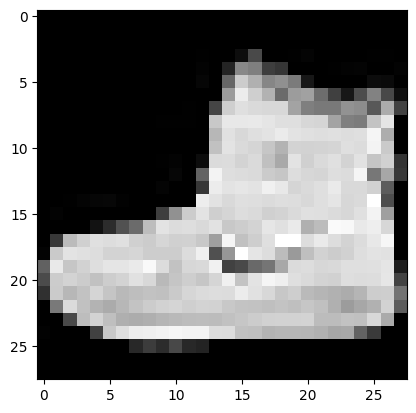

In [ ]:
image, label = training_data[0]
print(image.shape, label)

plt.imshow(image.squeeze(), cmap="gray")
plt.show()

### Writing your own Dataset

Your own data needs exactly three methods: `__init__` to set things up, `__len__` to say how many examples there are, and `__getitem__` to return the one at index `idx`.

The version below holds everything in memory, which is fine for small data. A realistic one stores paths in `__init__` and reads the file inside `__getitem__`, so only the examples actually being used are ever loaded.

In [ ]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, n):
        self.features = torch.randn(n, 3)
        self.labels = torch.randint(0, 2, (n,))

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


dataset = MyDataset(100)
print(len(dataset))
print(dataset[0])

100
(tensor([-0.1180,  0.2289,  0.0322]), tensor(0))


*We can now load a standard dataset, or wrap our own data so pytorch can read it.*

## 5.2 DataLoaders

A `DataLoader` turns a dataset into shuffled batches.

### Wrapping a dataset

`DataLoader` handles batching and shuffling. Shuffle the training data so the model does not see the same order every epoch; leave the test set unshuffled, since the order there does not matter and unshuffled is easier to debug. `len(loader)` is the number of batches, not the number of examples.

Three arguments worth knowing about for later: `num_workers=n` prepares batches on background processes, `drop_last=True` discards the short final batch, and `transforms.Compose` on the dataset side is where augmentation goes.

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64)

print(len(train_dataloader))

1875


### Iterating gives you batches

Looping over the loader yields `(features, labels)` with a batch dimension stacked on the front — the `torch.stack` from Topic 1, done for you. One full pass is one epoch.

That stacking step is `collate_fn`, and you can replace it. Anything whose examples are not all the same shape — variable-length sequences, most obviously — needs a custom one to pad the batch.

In [ ]:
images, labels = next(iter(train_dataloader))

print(images.shape)
print(labels.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


*We can now turn any dataset into shuffled batches with one line.*

## Walkthrough: the whole tutorial in one training loop

Everything from all five topics, doing the job it exists for. Reading down the cell: a **module** holding parameters, an **optimizer** pointed at those parameters, a **DataLoader** producing batches, **tensors** moved to the device, **autograd** filling in gradients, and the optimizer stepping.

The evaluation half is the same loop with the training parts removed: `eval()` mode, `no_grad()` for memory, and `max(dim=1)` to turn scores into predicted classes.

In [ ]:
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"


class Classifier(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(28 * 28, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 10),
        )

    def forward(self, images):
        return self.layers(images.view(images.shape[0], -1))


model = Classifier().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 1

for epoch in range(epochs):
    model.train()
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        loss = F.cross_entropy(model(images), labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_dataloader:
            images, labels = images.to(device), labels.to(device)
            values, predicted = model(images).max(dim=1)
            correct += (predicted == labels).sum().item()

    print(
        f"epoch {epoch}: train loss {loss.item():.4f}, test accuracy {correct / len(test_data):.4f}"
    )

epoch 0: train loss 0.3073, test accuracy 0.8507
